In [2]:
pip install tensorflow


  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached rich-14.1.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown-3.8.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/

In [4]:
# src/lstm_model.py
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Flatten, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

# -------------------------------
# Load and preprocess data
# -------------------------------
panel_path = "C:/Users/dedee/Downloads/epidemic-project/data_curated/panel_for_model.csv"
panel = pd.read_csv(panel_path, parse_dates=['Date'])

features = ['active','new_confirmed','daily_tests','daily_vax','vax_rate']
seq_len = 14  # lookback days

X_list, region_list, y_list = [], [], []
states = panel['state'].unique()

for st in states:
    sub = panel[panel['state']==st].sort_values('Date').reset_index(drop=True)
    if len(sub) <= seq_len:
        continue
    arr = sub[features].values
    for i in range(len(sub)-seq_len):
        X_list.append(arr[i:i+seq_len])
        region_list.append(int(sub.loc[i+seq_len, 'state_id']))
        y_list.append(sub.loc[i+seq_len, 'active'])

X = np.stack(X_list)
y = np.array(y_list)
region_idx = np.array(region_list)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of sequences:", len(y))

# -------------------------------
# Build LSTM model
# -------------------------------
seq_len = X.shape[1]
n_features = X.shape[2]
n_regions = int(region_idx.max()) + 1
embed_dim = 8

# model inputs
seq_in = Input(shape=(seq_len, n_features), name='seq_in')
region_in = Input(shape=(1,), dtype='int32', name='region_in')

# LSTM encoder
x = LSTM(64, activation='tanh', name='lstm_enc')(seq_in)
x = Dropout(0.2)(x)

# region embedding
emb = Embedding(input_dim=n_regions, output_dim=embed_dim, name='region_emb')(region_in)
embf = Flatten()(emb)

# concatenate
concat = Concatenate()([x, embf])
dense = Dense(64, activation='relu')(concat)
dense = Dropout(0.2)(dense)
out = Dense(1, activation='sigmoid')(dense)  # y is normalized

model = Model(inputs=[seq_in, region_in], outputs=out)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# -------------------------------
# Train/test split
# -------------------------------
X_train, X_test, region_train, region_test, y_train, y_test = train_test_split(
    X, region_idx, y, test_size=0.2, random_state=42, shuffle=True
)

# -------------------------------
# Train the model
# -------------------------------
history = model.fit(
    {'seq_in': X_train, 'region_in': region_train},
    y_train,
    validation_data=({'seq_in': X_test, 'region_in': region_test}, y_test),
    epochs=30,
    batch_size=64
)

# -------------------------------
# Save model
# -------------------------------
model.save('models/global_lstm.h5')
print("Model saved to models/global_lstm.h5")


X shape: (25117, 14, 5)
y shape: (25117,)
Number of sequences: 25117


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ seq_in (InputLayer)           │ (None, 14, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ region_in (InputLayer)        │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_enc (LSTM)               │ (None, 64)                │          17,920 │ seq_in[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ region_emb (Embedding)        │ (None, 1, 8)              │             368 │ region_in[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ lstm_enc[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 8)                 │               0 │ region_emb[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 72)                │               0 │ dropout[0][0],             │
│                               │                           │                 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           4,672 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 1)                 │              65 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 23,025 (89.94 KB)

 Trainable params: 23,025 (89.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0093 - mae: 0.0350 - val_loss: 0.0041 - val_mae: 0.0250
Epoch 2/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0013 - mae: 0.0163 - val_loss: 3.9137e-04 - val_mae: 0.0085
Epoch 3/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 3.2729e-04 - mae: 0.0087 - val_loss: 1.3165e-04 - val_mae: 0.0061
Epoch 4/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 2.2442e-04 - mae: 0.0073 - val_loss: 1.3061e-04 - val_mae: 0.0056
Epoch 5/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 1.8318e-04 - mae: 0.0067 - val_loss: 1.5294e-04 - val_mae: 0.0060
Epoch 6/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 1.5889e-04 - mae: 0.0063 - val_loss: 6.8497e-05 - val_mae: 0.0041
Epoch 7/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.3533e-04 - mae: 0.0058 - val_loss: 7.4221e-05 - val_mae: 0.0062
Epoch 8/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.3499e-04 - mae: 0.0057 - val_loss: 9.2352e-05 - val_mae: 0.

Model saved to models/global_lstm.h5


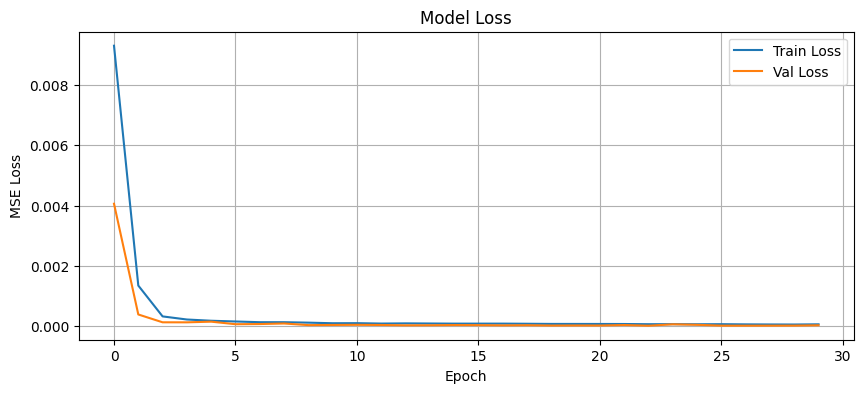

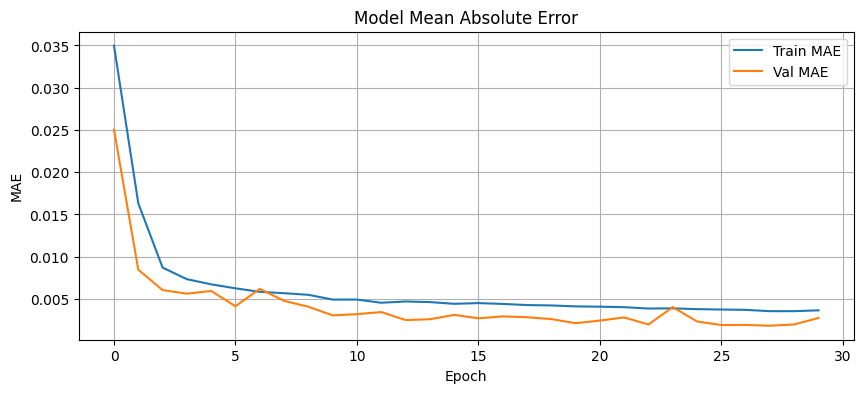

In [5]:
# Plot training history
import matplotlib.pyplot as plt

# Loss curve
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# MAE curve
plt.figure(figsize=(10,4))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# -------------------------------
# Make predictions
# -------------------------------
y_pred = model.predict({'seq_in': X_test, 'region_in': region_test}).flatten()

# Align test samples with state/date
# safer way: grab the rows in panel that match test indices
test_idx = np.arange(len(y))[int(len(y)*0.8):]  # last 20% if shuffle=False
# but since you used shuffle=True, better just store state/date when creating X_list

# For now, create a placeholder dataframe without dates (since shuffle breaks order)
df_out = pd.DataFrame({
    "prob": y_pred,         # model prediction
    "true_label": y_test,   # ground truth
    "region": region_test   # region index
})

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

df_out.to_csv(results_dir / "predictions_with_truth.csv", index=False)
print("✅ Saved:", results_dir / "predictions_with_truth.csv")


NameError: name 'model' is not defined

In [2]:
import tensorflow as tf

h5_path = r"C:\Users\dedee\Downloads\epidemic-project\models\global_lstm.h5"
old_model = tf.keras.models.load_model(h5_path, compile=False)

# Save as .keras format
new_path = r"C:\Users\dedee\Downloads\epidemic-project\models\global_lstm.keras"
old_model.save(new_path)

print(f"Model saved in Keras format at: {new_path}")



Model saved in Keras format at: C:\Users\dedee\Downloads\epidemic-project\models\global_lstm.keras


In [1]:
from tensorflow.keras.models import load_model

MODEL_LSTM_PATH = r"C:\Users\dedee\Downloads\epidemic-project\models\global_lstm.keras"

# Use tf.keras to load
lstm = load_model(MODEL_LSTM_PATH, compile=False)
